In [1]:
from matplotlib import colors
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from astropy.table import Table
import numpy as np
import os
import pandas as pd
import pathlib
import polars as pl

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
gaiaids = pl.read_parquet('(#path to#)allgaiadata.parq').to_pandas()

In [ ]:
gaiaids['abs_g_mag'] = gaiaids['phot_g_mean_mag'] - 5*np.log10(1000/gaiaids['parallax']) + 5

In [ ]:
reportedsample = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')

In [ ]:
reportedsample['bp-rp'] = reportedsample['phot_bp_mean_mag']-reportedsample['phot_rp_mean_mag']
reportedsample['abs_g_mag'] = reportedsample['phot_g_mean_mag'] - 5*np.log10(1000/reportedsample['parallax']) + 5

In [7]:
minra = np.nanmin(gaiaids['ra_rad'].values)
maxra = np.nanmax(gaiaids['ra_rad'].values)
mindec = np.nanmin(gaiaids['dec_rad'].values)
maxdec = np.nanmax(gaiaids['dec_rad'].values)
allbins, allx, ally = np.histogram2d(gaiaids['ra_rad'],gaiaids['dec_rad'],bins=200,range=[[minra,maxra],[mindec,maxdec]])
prebins, px, py = np.histogram2d(reportedsample['ra_rad'],reportedsample['dec_rad'], bins=200,range=[[minra,maxra],[mindec,maxdec]])
totdet_fracradec = prebins/allbins

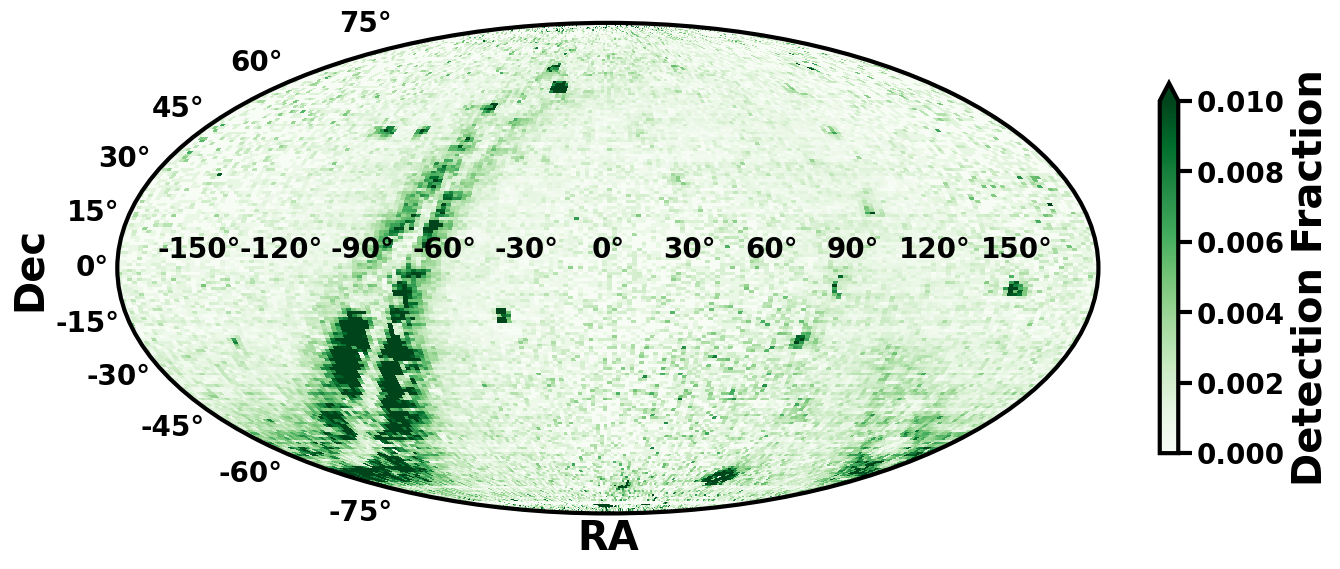

In [8]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='mollweide')
cmap = plt.cm.Greens
ax.pcolor(
    allx, ally,
    totdet_fracradec.T, cmap=cmap, shading='auto', vmin=0, vmax=0.01, rasterized=True)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(0, 0.01), cmap=cmap), ax=ax, shrink=0.5,  extend='max')
cbar.set_label("Detection Fraction")
ax.set_ylabel('Dec')
ax.set_xlabel('RA')
plt.tight_layout()
plt.savefig('mollweide_detfraction.pdf', dpi=300)
plt.show()

In [ ]:
gaiaids['abs_g_mag'] = gaiaids['phot_g_mean_mag'] - 5*np.log10(1000/gaiaids['parallax']) + 5
gaiaids['bp-rp'] = gaiaids['phot_bp_mean_mag'] - gaiaids['phot_rp_mean_mag']

In [10]:
minbprp = np.nanmin(gaiaids['bp-rp'].values)
maxbprp = np.nanmax(gaiaids['bp-rp'].values)
mingmag = np.nanmin(gaiaids['abs_g_mag'].values)
maxgmag = np.nanmax(gaiaids['abs_g_mag'].values)

In [11]:
allgaia, allx, ally = np.histogram2d(gaiaids['bp-rp'], gaiaids['abs_g_mag'],bins=250, range=[(minbprp, maxbprp), (mingmag, maxgmag)])
reported, reportedx, reportedy = np.histogram2d(reportedsample['bp-rp'], reportedsample['abs_g_mag'], bins=250, range=[(minbprp, maxbprp), (mingmag, maxgmag)])

truegaia = allgaia.T
truereported = reported.T

detectionfraction = truereported/truegaia
detectionfraction[np.isnan(detectionfraction)] = 0

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_67953/1431014464.py:7: RuntimeWarning: invalid value encountered in divide
  detectionfraction = truereported/truegaia


In [28]:
cmap = plt.colormaps['RdPu']

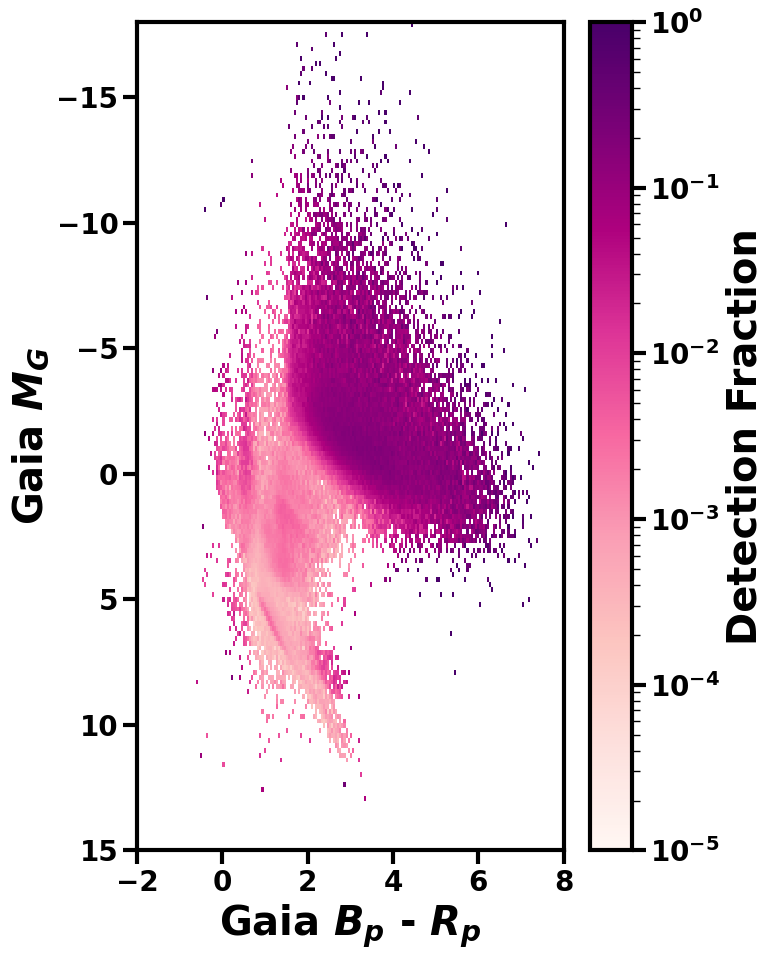

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
ax.set(xlim=(-2, 8), ylim=(15, -18), xlabel='Gaia $B_p$ - $R_p$', ylabel=f'Gaia $M_G$')
chehe = ax.pcolormesh(allx, ally,detectionfraction, shading='flat', cmap=cmap, norm=colors.LogNorm(vmin=0.00001, vmax=1), rasterized=True)
cbar = fig.colorbar(chehe, ax=ax)
cbar.set_label("Detection Fraction")
plt.tight_layout()
plt.savefig('hr_detfraction.pdf', dpi=300)
plt.show()